# 1. Data Processing

###  Load dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, HDBSCAN, \
    MiniBatchKMeans, DBSCAN, SpectralClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, \
    calinski_harabasz_score
from sklearn.decomposition import PCA
import umap
import warnings
warnings.filterwarnings('ignore')
from minisom import MiniSom
from sklearn.cluster import KMeans, AgglomerativeClustering, HDBSCAN, \
    MiniBatchKMeans, DBSCAN, SpectralClustering, OPTICS, MeanShift, \
    estimate_bandwidth
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, \
    calinski_harabasz_score
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import umap
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('C:\\Users\\Usuario\\Documents\\GitHub\\PFG\\Analizador\\pollution-particle-analyzer-main\\output\\particle_features_reso_cambiado.csv')


### View columns

In [4]:
print("\n Columns:", df.columns.tolist())


 Columns: ['image_name', 'area', 'perimeter', 'major_axis', 'minor_axis', 'aspect_ratio', 'eccentricity', 'equivalent_diameter', 'feret_max', 'feret_min', 'solidity', 'extent', 'convex_area', 'compactness', 'roundness', 'sphericity', 'rectangularity', 'convex_ratio', 'area_perimeter_ratio', 'mean_intensity', 'std_intensity', 'intensity_range', 'contrast_internal', 'intensity_entropy', 'local_variance', 'glcm_contrast', 'glcm_homogeneity', 'glcm_energy', 'glcm_correlation', 'lbp_mean', 'lbp_std', 'hu1', 'hu2', 'hu3', 'hu4', 'hu5', 'hu6', 'hu7', 'fractal_dimension', 'convexity_defects', 'hull_ratio', 'roughness_index', 'euler_number', 'holes']


### General information of the dataset

In [5]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 177277 entries, 0 to 177276
Data columns (total 44 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   image_name            177277 non-null  object 
 1   area                  177277 non-null  float64
 2   perimeter             177277 non-null  float64
 3   major_axis            177277 non-null  float64
 4   minor_axis            177277 non-null  float64
 5   aspect_ratio          177277 non-null  float64
 6   eccentricity          177277 non-null  float64
 7   equivalent_diameter   177277 non-null  float64
 8   feret_max             177277 non-null  float64
 9   feret_min             177277 non-null  float64
 10  solidity              177277 non-null  float64
 11  extent                177277 non-null  float64
 12  convex_area           177277 non-null  float64
 13  compactness           177277 non-null  float64
 14  roundness             177277 non-null  float64
 15  

### Numerical statistics

In [6]:
display(df.describe(include=[int, float]))

,area,perimeter,major_axis,minor_axis,aspect_ratio,eccentricity,equivalent_diameter,feret_max,feret_min,solidity,...,hu4,hu5,hu6,hu7,fractal_dimension,convexity_defects,hull_ratio,roughness_index,euler_number,holes
count,177277.000000,177277.000000,177277.000000,177277.000000,177277.000000,177277.000000,177277.000000,177277.000000,177277.000000,177277.000000,...,177277.000000,1.772770e+05,1.772770e+05,1.772770e+05,177277.000000,177277.000000,177277.000000,177277.000000,177277.000000,177277.000000
mean,38.024888,23.082822,9.736081,5.274024,1.913160,0.771959,6.300721,9.813522,5.274024,0.797131,...,0.001412,4.897651e-05,3.102528e-04,2.181981e-06,0.903727,7.152406,1.222976,1.070461,0.531439,0.468561
std,55.372283,21.405265,6.229913,2.994247,0.705521,0.160208,2.952246,5.983563,2.994247,0.143775,...,0.006284,1.491303e-03,3.161237e-03,5.961365e-04,0.051026,47.739425,0.309732,0.274662,1.132439,1.132439
min,12.000000,4.242641,3.829708,0.000000,1.000000,0.000000,3.908820,4.123106,0.000000,0.300000,...,0.000000,-1.219286e-02,-7.168574e-02,-1.069189e-01,0.581586,0.000000,0.000000,0.345494,-44.000000,0.000000
25%,16.000000,12.863961,6.238968,3.649061,1.362497,0.679430,4.513517,6.324555,3.649061,0.700000,...,0.000011,-1.687741e-11,-1.297077e-07,-8.412228e-09,0.871303,0.000000,1.007092,0.906416,1.000000,0.000000
50%,23.000000,17.071068,8.014989,4.497521,1.701403,0.809078,5.411516,8.062258,4.497521,0.825000,...,0.000085,1.308696e-09,5.917898e-07,0.000000e+00,0.907059,0.000000,1.235294,0.996181,1.000000,0.000000
75%,39.000000,25.313708,10.985175,5.957426,2.298908,0.900525,7.046726,11.180340,5.957426,0.916667,...,0.000632,2.735693e-07,3.334527e-05,9.410715e-09,0.937279,0.000000,1.444444,1.149125,1.000000,0.000000
max,1199.000000,606.321897,124.298094,70.255884,4.000000,1.000000,39.071911,97.416631,70.255884,1.000000,...,0.519351,3.380704e-01,3.282348e-01,7.453284e-02,1.098129,2253.500000,2.400000,5.192583,1.000000,45.000000


### Null values

In [7]:
print("\n Null values per column:")
print(df.isna().sum())



 Null values per column:
image_name              0
area                    0
perimeter               0
major_axis              0
minor_axis              0
aspect_ratio            0
eccentricity            0
equivalent_diameter     0
feret_max               0
feret_min               0
solidity                0
extent                  0
convex_area             0
compactness             0
roundness               0
sphericity              0
rectangularity          0
convex_ratio            0
area_perimeter_ratio    0
mean_intensity          0
std_intensity           0
intensity_range         0
contrast_internal       0
intensity_entropy       0
local_variance          0
glcm_contrast           0
glcm_homogeneity        0
glcm_energy             0
glcm_correlation        0
lbp_mean                0
lbp_std                 0
hu1                     0
hu2                     0
hu3                     0
hu4                     0
hu5                     0
hu6                     0
hu7         

### Infinite values

In [8]:
features = df.drop(columns=["image_name"], errors="ignore")
inf_rows = np.isinf(features).any(axis=1).sum()
print(f"Rows with inf o -inf: {inf_rows} de {len(features)}")

Rows with inf o -inf: 0 de 177277


In [9]:
features = df.drop(columns=["image_name"], errors="ignore")
inf_counts = np.isinf(features).sum()
print("Inf values per column:")
print(inf_counts[inf_counts > 0].sort_values(ascending=False))

Inf values per column:
Series([], dtype: int64)


### Variables correlation

Variables highly correlated (> 0.9):
area ↔ ['perimeter', 'equivalent_diameter', 'convex_area']
perimeter ↔ ['area', 'major_axis', 'equivalent_diameter', 'feret_max', 'convex_area', 'compactness']
major_axis ↔ ['perimeter', 'feret_max']
minor_axis ↔ ['equivalent_diameter']
equivalent_diameter ↔ ['area', 'perimeter', 'minor_axis', 'feret_max', 'feret_min']
feret_max ↔ ['perimeter', 'major_axis', 'equivalent_diameter']
feret_min ↔ ['equivalent_diameter']
solidity ↔ ['rectangularity']
convex_area ↔ ['area', 'perimeter', 'convexity_defects']
compactness ↔ ['perimeter', 'roughness_index']
rectangularity ↔ ['solidity', 'convex_ratio']
convex_ratio ↔ ['rectangularity']
std_intensity ↔ ['intensity_range', 'local_variance']
intensity_range ↔ ['std_intensity', 'local_variance']
local_variance ↔ ['std_intensity', 'intensity_range']
convexity_defects ↔ ['convex_area']
roughness_index ↔ ['compactness']


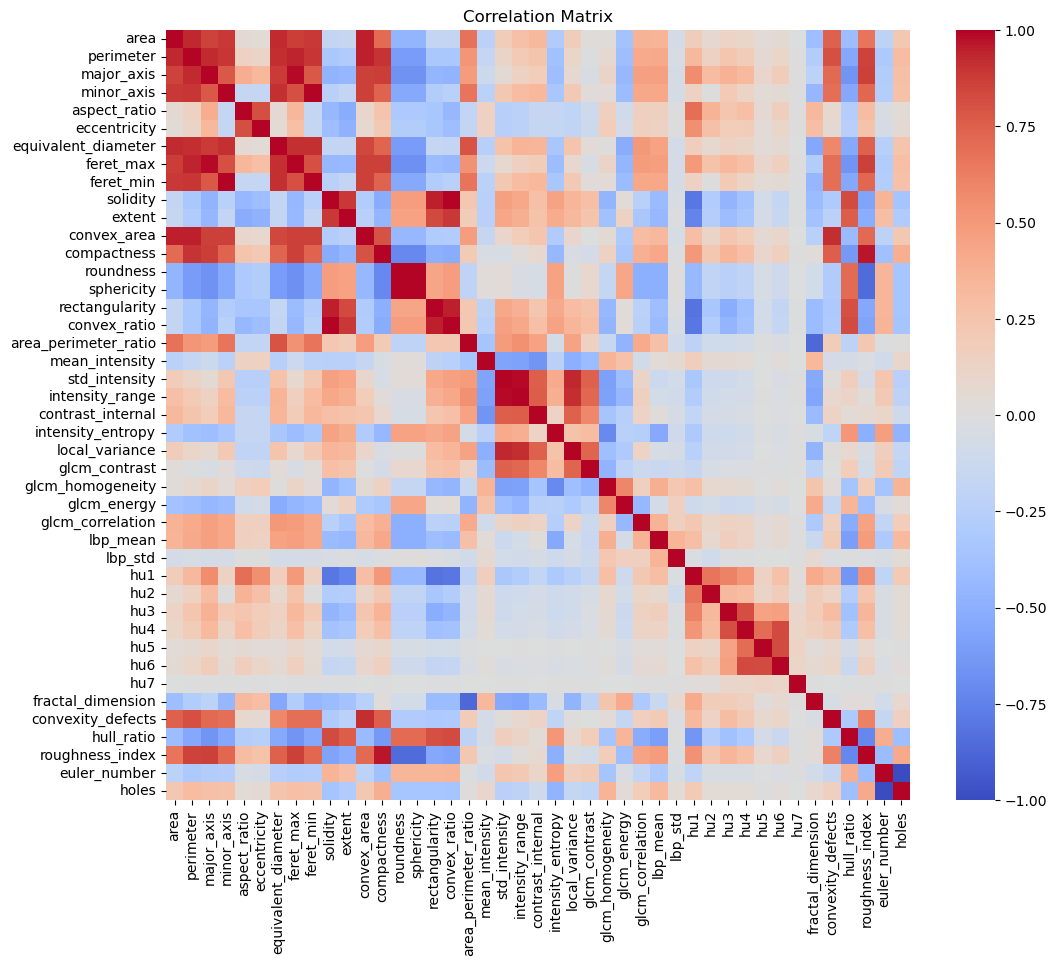

In [10]:
# Numerical Columns
numeric_df = df.select_dtypes(include=['int64', 'float64'])

#  Correlation matrix
corr_matrix = numeric_df.corr()

#  Highly correlated pairs
threshold = 0.9
high_corr = (corr_matrix.abs() > threshold) & (corr_matrix.abs() < 1.0)  
print("Variables highly correlated (> 0.9):")
for col in high_corr.columns:
    correlated_cols = high_corr.index[high_corr[col]].tolist()
    if correlated_cols:
        print(f"{col} ↔ {correlated_cols}")

# Correlation heatmap
plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

 Correlation Matrix — Updated Dataset

After correcting the feature extractor (fixing `convexity_defects`,
`hull_ratio`, and `fractal_dimension`), the correlation matrix reveals
some new relationships that were previously hidden by numerical artefacts:

- **`roundness` ↔ `fractal_dimension`** (>0.9) — now that `fractal_dimension`
  returns `NaN` instead of 0 for invalid cases, its real distribution emerges
  and shows a strong mathematical relationship with `roundness`, as both
  depend on the perimeter/area ratio.
- **`compactness` ↔ `roughness_index`** (>0.9) — a new redundancy detected,
  as both capture contour irregularity through similar geometric formulas.
- **`area_perimeter_ratio`** now correlates strongly with `roundness`,
  `sphericity` and `fractal_dimension`, forming a block of redundant
  shape descriptors.

The core structure remains unchanged: the size block (`area`, `perimeter`,
`equivalent_diameter`, `feret_max`, `convex_area`), the intensity block
(`std_intensity`, `intensity_range`, `local_variance`) and the Hu moments
block maintain the same correlations as before.

These new redundancies do not affect the clustering variable selection,
as `fractal_dimension`, `area_perimeter_ratio` and `roughness_index`
are not part of `columnas_clustering`.

### Data reduction

In [11]:
# Columns for clustering
columns_clustering = [
    # Size
    "perimeter",
    "equivalent_diameter",

    # Form
    "roundness",        
    "aspect_ratio",
    "compactness",
    "solidity",

    # Intensity / texture
    "mean_intensity",
    "std_intensity",
    "intensity_entropy",
    "glcm_energy",
    "glcm_correlation",
    "lbp_mean",

    # Invariant moments
    "hu1",
    "hu2",
    "hu4",
    "hu7",

    # Topology / morphology
    "euler_number",
    "holes",
    "convexity_defects"
]

df_clustering = df[columns_clustering].copy()
print("Columns for clustering:")
print(df_clustering.columns)
print("\nFirst rows of the dataset:")
print(df_clustering.head())

Columns for clustering:
Index(['perimeter', 'equivalent_diameter', 'roundness', 'aspect_ratio',
       'compactness', 'solidity', 'mean_intensity', 'std_intensity',
       'intensity_entropy', 'glcm_energy', 'glcm_correlation', 'lbp_mean',
       'hu1', 'hu2', 'hu4', 'hu7', 'euler_number', 'holes',
       'convexity_defects'],
      dtype='object')

First rows of the dataset:
   perimeter  equivalent_diameter  roundness  aspect_ratio  compactness  \
0  17.313708             5.970821   1.173783      1.067204    10.705875   
1  25.142136             7.312733   0.834939      1.105545    15.050642   
2  25.520815             7.978846   0.964697      1.209725    13.026240   
3  41.798990            12.964090   0.949407      1.427968    13.236027   
4  27.313708             8.667245   0.993804      1.456238    12.644723   

   solidity  mean_intensity  std_intensity  intensity_entropy  glcm_energy  \
0  0.933333      128.678571       3.625836           3.263537     0.144338   
1  0.875000   

### Null values

In [12]:
print("\n Null values by column:")
print(df_clustering.isna().sum())


 Null values by column:
perimeter              0
equivalent_diameter    0
roundness              0
aspect_ratio           0
compactness            0
solidity               0
mean_intensity         0
std_intensity          0
intensity_entropy      0
glcm_energy            0
glcm_correlation       0
lbp_mean               0
hu1                    0
hu2                    0
hu4                    0
hu7                    0
euler_number           0
holes                  0
convexity_defects      0
dtype: int64


### Noisy data 




🔹 perimeter
count    177277.000000
mean         23.082822
std          21.405265
min           4.242641
1%            9.242641
50%          17.071068
99%         104.597980
max         606.321897
Name: perimeter, dtype: float64


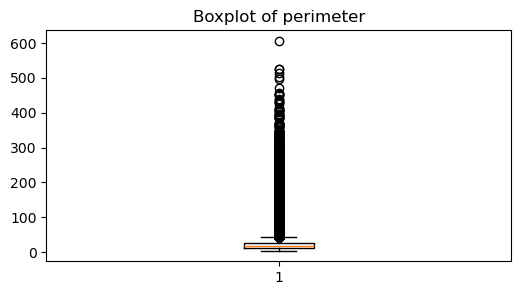


🔹 equivalent_diameter
count    177277.000000
mean          6.300721
std           2.952246
min           3.908820
1%            3.908820
50%           5.411516
99%          17.805523
max          39.071911
Name: equivalent_diameter, dtype: float64


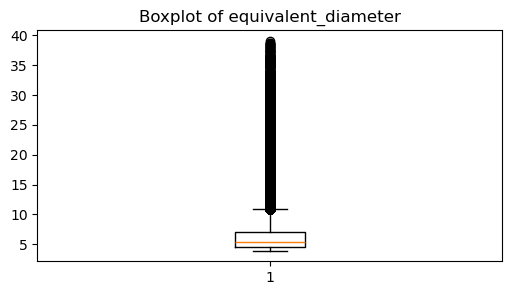


🔹 roundness
count    177277.000000
mean          0.993346
std           0.361046
min           0.037088
1%            0.222194
50%           1.007681
99%           1.934748
max           8.377580
Name: roundness, dtype: float64


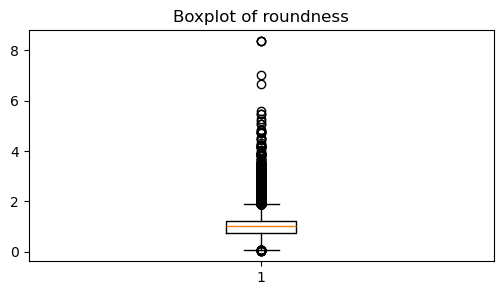


🔹 aspect_ratio
count    177277.000000
mean          1.913160
std           0.705521
min           1.000000
1%            1.041653
50%           1.701403
99%           3.861083
max           4.000000
Name: aspect_ratio, dtype: float64


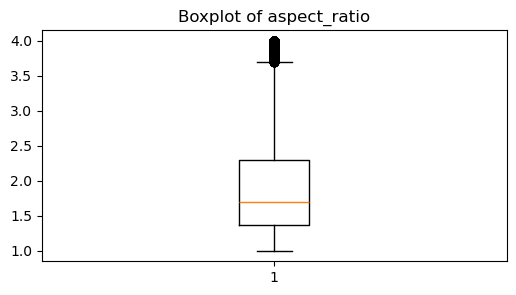


🔹 compactness
count    177277.000000
mean         15.347640
std          10.396130
min           1.500000
1%            6.495094
50%          12.470580
99%          56.555875
max         338.826030
Name: compactness, dtype: float64


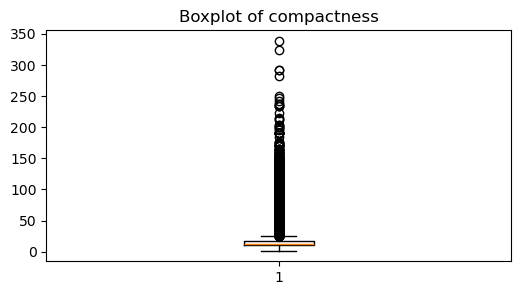


🔹 solidity
count    177277.000000
mean          0.797131
std           0.143775
min           0.300000
1%            0.431034
50%           0.825000
99%           1.000000
max           1.000000
Name: solidity, dtype: float64


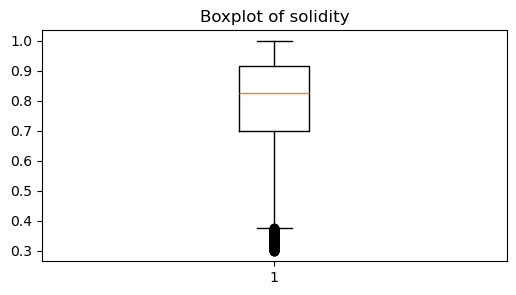


🔹 mean_intensity
count    177277.000000
mean        130.414582
std          28.330553
min           0.000000
1%           47.070482
50%         134.350000
99%         185.873529
max         241.633333
Name: mean_intensity, dtype: float64


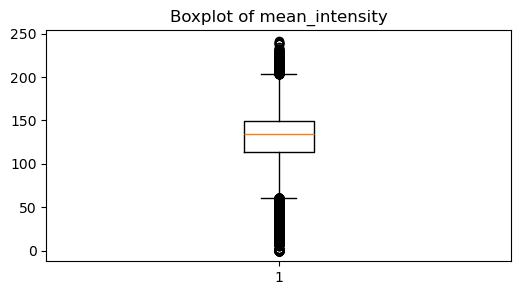


🔹 std_intensity
count    177277.000000
mean          8.645325
std           8.365184
min           0.000000
1%            0.577350
50%           5.615059
99%          36.846376
max          55.540956
Name: std_intensity, dtype: float64


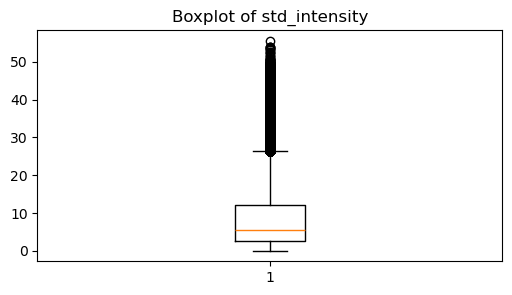


🔹 intensity_entropy
count    177277.000000
mean          3.265247
std           0.157520
min           1.001518
1%            2.646228
50%           3.321309
99%           3.398788
max           3.431487
Name: intensity_entropy, dtype: float64


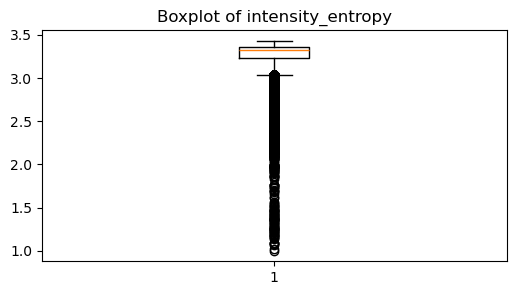


🔹 glcm_energy
count    177277.000000
mean          0.153681
std           0.070118
min           0.000000
1%            0.041138
50%           0.146969
99%           0.407574
max           1.000000
Name: glcm_energy, dtype: float64


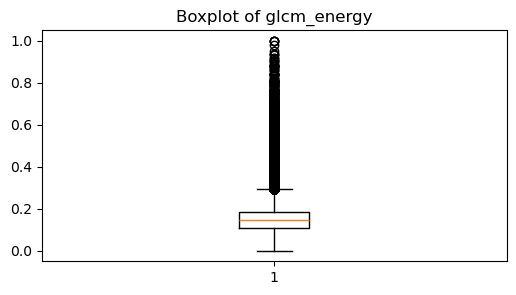


🔹 glcm_correlation
count    177277.000000
mean          0.673441
std           0.220390
min          -0.866033
1%           -0.026924
50%           0.720666
99%           0.969620
max           1.000000
Name: glcm_correlation, dtype: float64


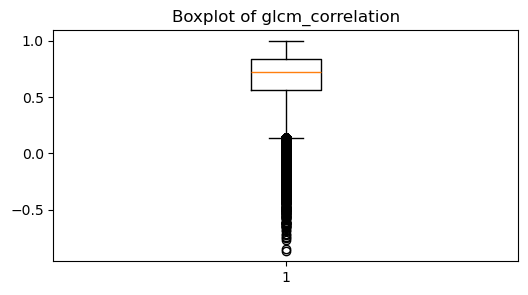


🔹 lbp_mean
count    177277.000000
mean        100.513418
std          18.455791
min           7.166667
1%           59.166667
50%         100.228571
99%         147.266667
max         255.000000
Name: lbp_mean, dtype: float64


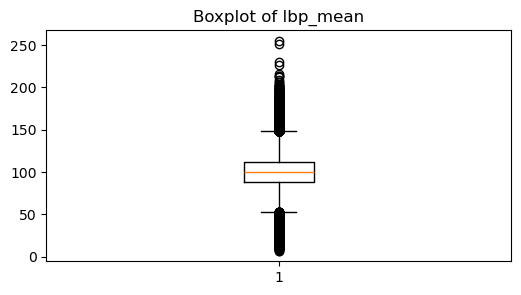


🔹 hu1
count    177277.000000
mean          0.252339
std           0.108097
min           0.152778
1%            0.156444
50%           0.214355
99%           0.624379
max           4.081633
Name: hu1, dtype: float64


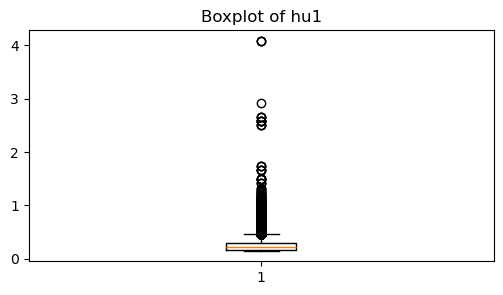


🔹 hu2
count    177277.000000
mean          0.032949
std           0.107412
min           0.000000
1%            0.000053
50%           0.010781
99%           0.256561
max          16.659725
Name: hu2, dtype: float64


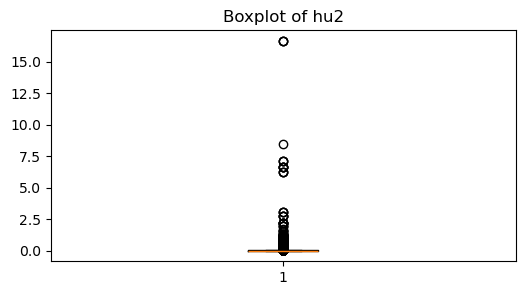


🔹 hu4
count    177277.000000
mean          0.001412
std           0.006284
min           0.000000
1%            0.000000
50%           0.000085
99%           0.022598
max           0.519351
Name: hu4, dtype: float64


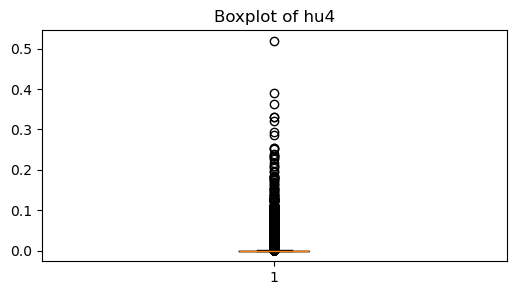


🔹 hu7
count    177277.000000
mean          0.000002
std           0.000596
min          -0.106919
1%           -0.000095
50%           0.000000
99%           0.000098
max           0.074533
Name: hu7, dtype: float64


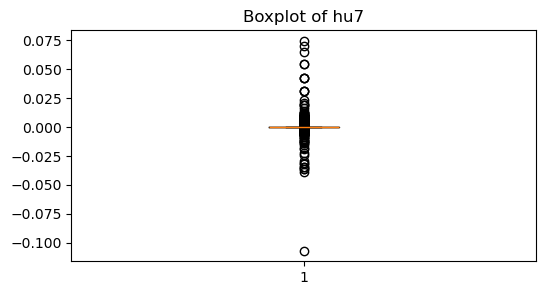


🔹 euler_number
count    177277.000000
mean          0.531439
std           1.132439
min         -44.000000
1%           -4.000000
50%           1.000000
99%           1.000000
max           1.000000
Name: euler_number, dtype: float64


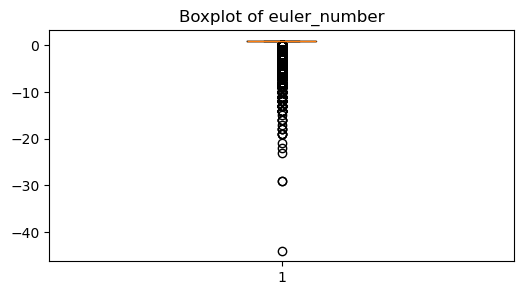


🔹 holes
count    177277.000000
mean          0.468561
std           1.132439
min           0.000000
1%            0.000000
50%           0.000000
99%           5.000000
max          45.000000
Name: holes, dtype: float64


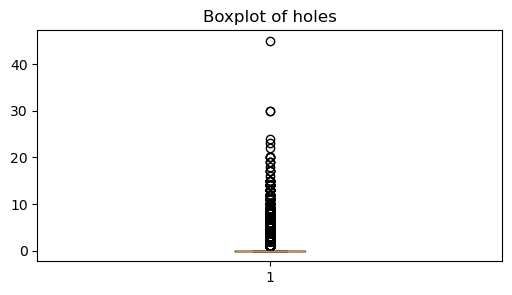


🔹 convexity_defects
count    177277.000000
mean          7.152406
std          47.739425
min           0.000000
1%            0.000000
50%           0.000000
99%         133.500000
max        2253.500000
Name: convexity_defects, dtype: float64


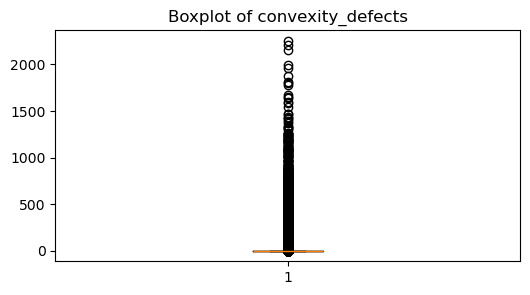

In [13]:
for col in df_clustering.columns:
    print(f"\n🔹 {col}")
    print(df_clustering[col].describe(percentiles=[0.01, 0.99]))
    
    plt.figure(figsize=(6,3))
    plt.boxplot(df_clustering[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

 Impact of resolution change on feature distributions

Increasing the processing resolution from 1,000×1,000 to 2,000×2,000 pixels
produced significant changes in the feature distributions, as each particle
now occupies approximately 4× more pixels, making geometric and texture
descriptors substantially more stable and reliable.

 Variables that improved significantly

- **`roundness`** — the most dramatic improvement. Previously the distribution
  was severely distorted (mean=5.15, max=86.24) due to perimeter instability
  at low resolution, requiring an inversion correction (`1/x`). At 2,000×2,000
  the distribution is now physically coherent (mean=0.99, median=1.007, max=8.38),
  with values centred around the theoretical limit of 1.0 for circular particles.
  The inversion correction is no longer needed.

- **`solidity`** — previously collapsed near 1.0 with almost no variance
  (median=1.000). Now shows a well-spread distribution (median=0.825,
  range 0.3–1.0), reflecting genuine shape complexity in larger particles
  that could not be captured at lower resolution.

- **`glcm_correlation`** — previously weakly distributed (median=0.241).
  Now strongly structured (median=0.721, mean=0.673), reflecting real
  spatial correlation patterns in particle texture that emerge when particles
  occupy more pixels.

- **`glcm_energy`** — previously concentrated at high values (median=0.323).
  Now lower and more spread (median=0.147), capturing genuine texture
  heterogeneity that was invisible at 1,000×1,000.

- **`lbp_mean`** — now better centred (median=100.2 vs 67.5) with a more
  symmetric distribution, reflecting richer and more stable local texture
  patterns.

- **`intensity_entropy`** — previously highly concentrated (std=0.072).
  Now more spread (std=0.158), capturing real variation in pixel intensity
  distribution within particles.

 Variables that worsened or require attention

- **`euler_number` and `holes`** — both deteriorated significantly.
  `euler_number` now reaches -44 (previously -9) and `holes` shows extreme
  outliers. At higher resolution, the segmentation pipeline detects more
  topological features (holes, loops) within particle contours, many of
  which are likely segmentation artefacts rather than real topology. These
  two variables will be excluded from clustering.

- **`convexity_defects`** — the maximum jumped from 546 to 2,253. This is
  expected: larger particles have larger absolute convex hull defect areas.
  This variable should be normalised by area (`convexity_defects / area`)
  before use, or excluded in favour of `solidity` which captures the same
  information in a scale-independent way.

- **`compactness`** — the median increased from 5.3 to 12.5. With longer
  perimeters at higher resolution, absolute compactness values scale up.
  The `log1p` transformation applied previously remains appropriate.

 Overall assessment

The resolution increase substantially improved the quality and reliability
of shape and texture descriptors. The most informative variables for
clustering (`roundness`, `solidity`, `glcm_correlation`, `glcm_energy`,
`lbp_mean`) now have distributions that genuinely reflect particle
morphology rather than pixel discretization artefacts. The key trade-off
is that `euler_number`, `holes` and raw `convexity_defects` have become
less reliable and should be treated with caution or excluded.

### Outliers treatment

In [14]:
cols_base = [
    "perimeter", "equivalent_diameter",
    "roundness", "aspect_ratio", "compactness", "solidity",
    "mean_intensity", "std_intensity", "intensity_entropy",
    "glcm_energy", "glcm_correlation", "lbp_mean",
    "hu1", "hu2", "hu4",
    "feret_min", "feret_max", "convexity_defects", "area"
]

df_clustering = df[cols_base].copy()

# Calcular nuevas variables
df_clustering['feret_ratio'] = np.where(
    df_clustering['feret_max'] > 0,
    df_clustering['feret_min'] / df_clustering['feret_max'],
    0
)

df_clustering['convexity_defects_norm'] = np.where(
    df_clustering['area'] > 0,
    df_clustering['convexity_defects'] / df_clustering['area'],
    0
)

# Quedarse solo con las columnas finales
columnas_clustering = [
    "perimeter", "equivalent_diameter",
    "roundness", "aspect_ratio", "compactness", "solidity", "feret_ratio",
    "mean_intensity", "std_intensity", "intensity_entropy",
    "glcm_energy", "glcm_correlation", "lbp_mean",
    "hu1", "hu2", "hu4",
    "convexity_defects_norm"
]

df_clustering = df_clustering[columnas_clustering].copy()
print(f"Variables para clustering: {len(columnas_clustering)}")
print(f"Dataset: {len(df_clustering)} partículas")

Variables para clustering: 17
Dataset: 177277 partículas


In [15]:
df_clean = df_clustering.copy()

p99_round  = df_clean['roundness'].quantile(0.99)
p1_energy  = df_clean['glcm_energy'].quantile(0.01)
p99_energy = df_clean['glcm_energy'].quantile(0.99)
p1_corr    = df_clean['glcm_correlation'].quantile(0.01)
p99_corr   = df_clean['glcm_correlation'].quantile(0.99)

# 1. Límites físicos
df_clean['roundness']        = df_clean['roundness'].clip(upper=p99_round)
df_clean['solidity']         = df_clean['solidity'].clip(0.0, 1.0)
df_clean['glcm_energy']      = df_clean['glcm_energy'].clip(p1_energy, p99_energy)
df_clean['glcm_correlation'] = df_clean['glcm_correlation'].clip(p1_corr, p99_corr)
df_clean['aspect_ratio']     = df_clean['aspect_ratio'].clip(1.0, 4.0)
df_clean['feret_ratio']      = df_clean['feret_ratio'].clip(0.0, 1.0)
df_clean['convexity_defects_norm'] = df_clean['convexity_defects_norm'].clip(lower=0.0)

# 2. Asimétricas → log1p + p99
for var in ['perimeter', 'compactness', 'hu1', 'hu2', 'hu4']:
    p99 = df_clean[var].quantile(0.99)
    df_clean[var] = df_clean[var].clip(upper=p99)
    df_clean[var] = np.log1p(df_clean[var])

# 3. Solo winsorizar
for var in ['equivalent_diameter', 'lbp_mean', 'std_intensity']:
    df_clean[var] = df_clean[var].clip(upper=df_clean[var].quantile(0.99))

# intensity_entropy: ambas colas
p5_ent  = df_clean['intensity_entropy'].quantile(0.05)
p99_ent = df_clean['intensity_entropy'].quantile(0.99)
df_clean['intensity_entropy'] = df_clean['intensity_entropy'].clip(p5_ent, p99_ent)

# 4. Eliminar convexity_defects_norm — IQR=0, 76.7% son exactamente 0
columnas_clustering = [c for c in columnas_clustering
                       if c != 'convexity_defects_norm']
df_clean = df_clean[columnas_clustering].copy()

print(f"Variables finales: {len(columnas_clustering)}")
print(columnas_clustering)

Variables finales: 16
['perimeter', 'equivalent_diameter', 'roundness', 'aspect_ratio', 'compactness', 'solidity', 'feret_ratio', 'mean_intensity', 'std_intensity', 'intensity_entropy', 'glcm_energy', 'glcm_correlation', 'lbp_mean', 'hu1', 'hu2', 'hu4']


#### Outlier Treatment Summary

#### Variable removal

Four variables were removed from the clustering feature set after outlier
analysis at 2,000×2,000 resolution:

- **`hu7`**: values fall in the 1e-5 scale, numerically unstable for the
  particles in this dataset. The signal-to-noise ratio is too low to be
  meaningful for clustering.

- **`euler_number`** and **`holes`**: at 2,000×2,000 resolution the
  segmentation pipeline detects significantly more topological features
  within particle contours (`euler_number` reaching -44, previously -9),
  many of which are likely artefacts rather than real topology. As `holes`
  is perfectly redundant with `euler_number` (`holes = 1 - euler_number`),
  both are excluded.

- **`convexity_defects_norm`** (`convexity_defects / area`): 76.7% of
  values are exactly 0 — most particles have no convex hull defects. The
  IQR is 0, making `RobustScaler` unable to scale this variable meaningfully.
  It provides no discriminative information for clustering.

#### Variable recovered

- **`roundness`**: previously removed at 1,000×1,000 resolution because
  91.2% of values exceeded the theoretical maximum of 1 due to pixel-grid
  discretization. At 2,000×2,000 the distribution is now physically coherent
  (median=1.007, max=8.38), with values correctly centred around 1.0. The
  inversion correction (`1/x`) applied in the previous dataset is no longer
  needed. `roundness` is restored to the feature set.

#### Variable added

- **`feret_ratio`** (`feret_min / feret_max`): a scale-independent shape
  descriptor that captures particle elongation more robustly than
  `aspect_ratio` for irregular particles. Bounded [0, 1] by definition.

#### Outlier treatment applied to remaining variables

The treatment strategy was determined per variable based on physical limits,
distribution shape, and domain knowledge:

- **Physical limits** (`solidity`, `glcm_energy`, `glcm_correlation`,
  `aspect_ratio`, `feret_ratio`) → clipped to their valid mathematical
  or extractor-defined range. `glcm_energy` and `glcm_correlation` are
  additionally winsorized at p1/p99 to prevent RobustScaler amplification
  of residual tail values.

- **Skewed distributions** (`perimeter`, `compactness`, `hu1`, `hu2`,
  `hu4`) → winsorized at p99, then `log1p` transformation to reduce the
  effect of the long upper tail.

- **Winsorize only** (`equivalent_diameter`, `lbp_mean`, `std_intensity`)
  → clipped at p99 without log transformation, as their distributions are
  near-normal or on a linear scale where log would have no physical meaning.

- **Both tails winsorized** (`roundness` at p99, `intensity_entropy` at
  p5/p99) → these variables have meaningful lower bounds that also require
  clipping to prevent extreme scaled values.

- **No treatment** (`mean_intensity`, `solidity`, `feret_ratio`,
  `aspect_ratio`) → distributions already within valid physical bounds
  with no extreme outliers requiring correction beyond the hard clip.



# 2. Feature Scaling

In [16]:
# hu4: StandardScaler (IQR demasiado pequeño)
hu4_scaler = StandardScaler()
df_clean['hu4'] = hu4_scaler.fit_transform(df_clean[['hu4']])

# Resto: RobustScaler
cols_robust = [c for c in df_clean.columns if c != 'hu4']
scaler = RobustScaler()
X_robust = scaler.fit_transform(df_clean[cols_robust])

X_scaled = pd.DataFrame(X_robust, columns=cols_robust, index=df_clean.index)
X_scaled['hu4'] = df_clean['hu4'].values

print(f"\n{'Variable':<28} {'Median':>8} {'IQR':>8} {'Min':>8} {'Max':>8}")
print("-" * 60)
for col in X_scaled.columns:
    q1 = X_scaled[col].quantile(0.25)
    q3 = X_scaled[col].quantile(0.75)
    print(f"{col:<28} {X_scaled[col].median():>8.3f} "
          f"{q3-q1:>8.3f} "
          f"{X_scaled[col].min():>8.3f} "
          f"{X_scaled[col].max():>8.3f}")

print(f"\nShape: {X_scaled.shape}")
print(f"NaN: {X_scaled.isna().sum().sum()}")


Variable                       Median      IQR      Min      Max
------------------------------------------------------------
perimeter                       0.000    1.000   -1.931    2.755
equivalent_diameter             0.000    1.000   -0.593    4.893
roundness                       0.000    1.000   -2.111    2.016
aspect_ratio                    0.000    1.000   -0.749    2.455
compactness                     0.000    1.000   -3.823    3.296
solidity                        0.000    1.000   -2.423    0.808
feret_ratio                     0.000    1.000   -2.250    1.651
mean_intensity                  0.000    1.000   -3.767    3.008
std_intensity                   0.000    1.000   -0.589    3.278
intensity_entropy               0.000    1.000   -2.852    0.602
glcm_energy                     0.000    1.000   -1.441    3.547
glcm_correlation                0.000    1.000   -2.668    0.888
lbp_mean                        0.000    1.000   -3.890    1.966
hu1                         

### Scaling

- **`hu4`** → `StandardScaler`, as its IQR is too small relative to the
  tail for `RobustScaler` to work correctly.
- **All other variables** → `RobustScaler`, which centres on the median
  and scales by the IQR, making it robust to any moderate residual outliers
  remaining after the transformations above.

The final feature set contains **16 variables** across five categories:
size (2), shape (5), intensity/texture (6), and Hu moments (3).

# 3. Clustering

## 3.1 Initial exploration

Two preliminary analyses are run before the full comparison:
- **HDBSCAN on the full dataset** — density-based, no k required, gives a
  first estimate of the natural number of clusters
- **Elbow + Silhouette for KMeans** — guides the choice of k for
  partition-based methods

In [ ]:
# ── HDBSCAN on full dataset ────────────────────────────────────────
print("Running HDBSCAN on full dataset...")
hdb_full = HDBSCAN(min_cluster_size=50, min_samples=10,
                   cluster_selection_method='eom')
labels_hdb_full = hdb_full.fit_predict(X_scaled)

n_hdb  = len(set(labels_hdb_full)) - (1 if -1 in labels_hdb_full else 0)
noise  = (labels_hdb_full == -1).sum()
mask   = labels_hdb_full != -1

print(f"  Clusters found: {n_hdb}")
print(f"  Noise points:   {noise} ({noise/len(labels_hdb_full)*100:.1f}%)")
if n_hdb > 1:
    sil = silhouette_score(X_scaled[mask], labels_hdb_full[mask],
                           sample_size=10000, random_state=42)
    print(f"  Silhouette:     {sil:.4f}")

Running HDBSCAN on full dataset...


The elbow curve shows no clear inflection point, and the silhouette score
peaks at k=2 and decreases monotonically — consistent with the 2,000×2,000
dataset. However, HDBSCAN finds 148 clusters with 54.1% noise and
silhouette=-0.03, indicating that the data structure at 1,000×1,000
resolution is dominated by pixel-area quantization artefacts rather than
genuine morphological groups.

Running elbow + silhouette for KMeans...
  k=2  inertia=1527529.8  silhouette=0.3350
  k=3  inertia=1288861.3  silhouette=0.2569
  k=4  inertia=1136755.3  silhouette=0.2075
  k=5  inertia=1012673.7  silhouette=0.2102
  k=6  inertia=926799.3  silhouette=0.2117
  k=7  inertia=874982.0  silhouette=0.1794
  k=8  inertia=829242.1  silhouette=0.1964
  k=9  inertia=787339.9  silhouette=0.1867
  k=10  inertia=750623.0  silhouette=0.1717


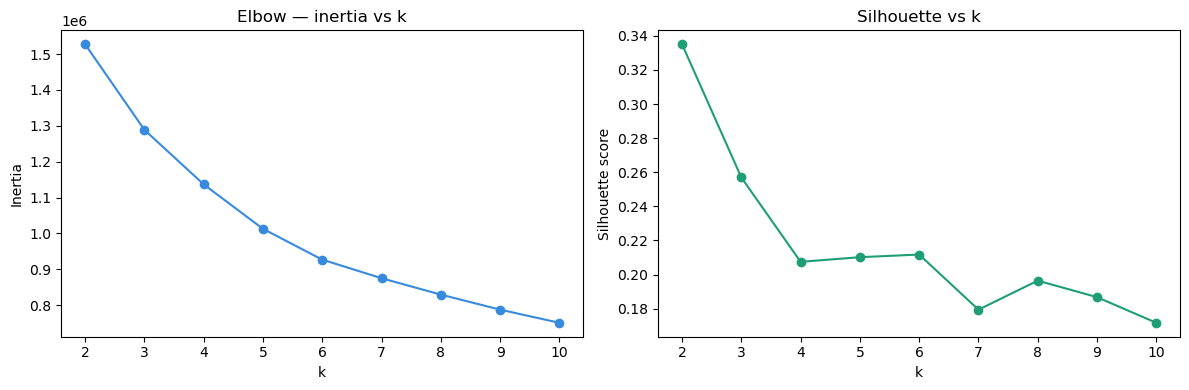

In [18]:
# Elbow + Silhouette for KMeans
print("Running elbow + silhouette for KMeans...")
K_RANGE     = range(2, 11)
inertias    = []
silhouettes = []

for k in K_RANGE:
    km = KMeans(n_clusters=k, init='k-means++', n_init=15, random_state=42)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels,
                                        sample_size=10000, random_state=42))
    print(f"  k={k}  inertia={km.inertia_:.1f}  silhouette={silhouettes[-1]:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(K_RANGE), inertias, 'o-', color='#378ADD')
axes[0].set_title('Elbow — inertia vs k')
axes[0].set_xlabel('k'); axes[0].set_ylabel('Inertia')
axes[1].plot(list(K_RANGE), silhouettes, 'o-', color='#1D9E75')
axes[1].set_title('Silhouette vs k')
axes[1].set_xlabel('k'); axes[1].set_ylabel('Silhouette score')
plt.tight_layout()
plt.savefig('elbow_silhouette_2000.png', dpi=150, bbox_inches='tight')
plt.show()

## 3.2 Algorithm Comparison

### 3.1 Partitioning Based

In [19]:
SAMPLE_SIZE = 10000
np.random.seed(42)
idx_sample = np.random.choice(len(X_scaled), SAMPLE_SIZE, replace=False)
X_sample   = X_scaled.iloc[idx_sample]

results         = {}
N_CLUSTERS_LIST = [2, 3, 4]

print(f"{'Algorithm':<22} {'k':>3} {'Silhouette':>12} {'DB↓':>10} {'CH↑':>12} {'Note'}")
print("-" * 75)

# KMeans 
for k in N_CLUSTERS_LIST:
    km = KMeans(n_clusters=k, init='k-means++', n_init=15, random_state=42)
    labels = km.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels, sample_size=10000, random_state=42)
    db  = davies_bouldin_score(X_scaled, labels)
    ch  = calinski_harabasz_score(X_scaled, labels)
    results[f"KMeans_k{k}"] = {'labels': labels, 'silhouette': sil,
                                'davies_bouldin': db, 'calinski': ch}
    print(f"{'KMeans':<22} {k:>3} {sil:>12.4f} {db:>10.4f} {ch:>12.1f} full dataset")

# MiniBatchKMeans 
for k in N_CLUSTERS_LIST:
    mb = MiniBatchKMeans(n_clusters=k, n_init=10, random_state=42,
                         batch_size=10000)
    labels = mb.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels, sample_size=10000, random_state=42)
    db  = davies_bouldin_score(X_scaled, labels)
    ch  = calinski_harabasz_score(X_scaled, labels)
    results[f"MiniBatchKMeans_k{k}"] = {'labels': labels, 'silhouette': sil,
                                         'davies_bouldin': db, 'calinski': ch}
    print(f"{'MiniBatchKMeans':<22} {k:>3} {sil:>12.4f} {db:>10.4f} {ch:>12.1f} full dataset")

# GMM 
for k in N_CLUSTERS_LIST:
    gmm = GaussianMixture(n_components=k, n_init=3, random_state=42)
    gmm.fit(X_scaled)
    labels = gmm.predict(X_scaled)
    sil = silhouette_score(X_scaled, labels, sample_size=10000, random_state=42)
    db  = davies_bouldin_score(X_scaled, labels)
    ch  = calinski_harabasz_score(X_scaled, labels)
    results[f"GMM_k{k}"] = {'labels': labels, 'silhouette': sil,
                              'davies_bouldin': db, 'calinski': ch}
    print(f"{'GMM':<22} {k:>3} {sil:>12.4f} {db:>10.4f} {ch:>12.1f} full dataset")



Algorithm                k   Silhouette        DB↓          CH↑ Note
---------------------------------------------------------------------------
KMeans                   2       0.3350     1.4880      65908.3 full dataset
KMeans                   3       0.2569     1.4957      55469.9 full dataset
KMeans                   4       0.2075     1.4716      49834.7 full dataset
MiniBatchKMeans          2       0.3405     1.4791      65871.5 full dataset
MiniBatchKMeans          3       0.1761     1.7230      48295.2 full dataset
MiniBatchKMeans          4       0.2319     1.4928      49446.9 full dataset
GMM                      2       0.1758     1.8280      40428.5 full dataset
GMM                      3       0.1133     1.8606      39610.4 full dataset
GMM                      4       0.0959     1.7703      35523.2 full dataset


### 3.2 Hierarchical

In [20]:
# Agglomerative
for k in N_CLUSTERS_LIST:
    agg = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels_sample = agg.fit_predict(X_sample)
    sil = silhouette_score(X_sample, labels_sample, random_state=42)
    db  = davies_bouldin_score(X_sample, labels_sample)
    ch  = calinski_harabasz_score(X_sample, labels_sample)
    results[f"Agglomerative_k{k}"] = {'labels': labels_sample,
                                       'silhouette': sil,
                                       'davies_bouldin': db, 'calinski': ch}
    print(f"{'Agglomerative':<22} {k:>3} {sil:>12.4f} {db:>10.4f} {ch:>12.1f} sample n={SAMPLE_SIZE}")



Agglomerative            2       0.3389     1.5396       3357.4 sample n=10000
Agglomerative            3       0.3280     1.5840       2465.6 sample n=10000
Agglomerative            4       0.1336     1.8891       2212.8 sample n=10000


### 3.3 Density Based

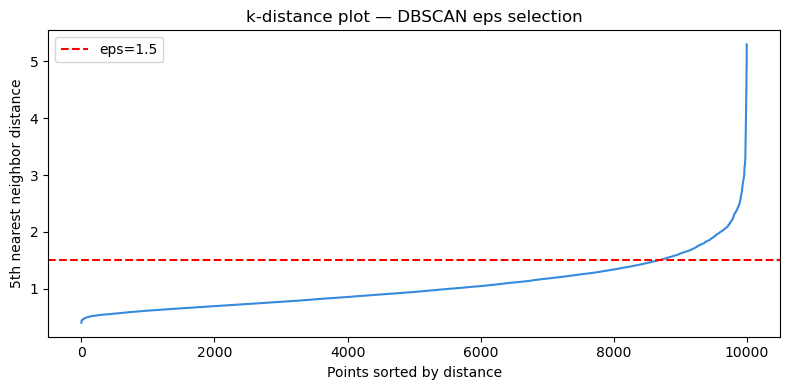

DBSCAN                 auto       0.2033     0.9414         74.4 eps=1.0 k=4 noise=42.7% sample
DBSCAN                 auto       0.6357     0.3643        128.0 eps=1.5 k=2 noise=11.3% sample
DBSCAN eps=2.0: k=1 — no valid clusters
OPTICS: k=1 — no valid clusters

Estimating bandwidth for Mean Shift (may take ~1 min)...
MeanShift              auto       0.3575     1.2315        752.6 k=5 sample n=10000


In [21]:
# ── Density-based — sample only ───────────────────────────────────
# HDBSCAN
hdb_s = HDBSCAN(min_cluster_size=100, min_samples=10,
                cluster_selection_method='eom')
labels_hdb_s = hdb_s.fit_predict(X_sample)
mask_s   = labels_hdb_s != -1
n_hdb_s  = len(set(labels_hdb_s[mask_s]))
noise_s  = (labels_hdb_s == -1).mean() * 100
if n_hdb_s > 1:
    sil = silhouette_score(X_sample[mask_s], labels_hdb_s[mask_s],
                           random_state=42)
    db  = davies_bouldin_score(X_sample[mask_s], labels_hdb_s[mask_s])
    ch  = calinski_harabasz_score(X_sample[mask_s], labels_hdb_s[mask_s])
    results['HDBSCAN_sample'] = {'labels': labels_hdb_s, 'silhouette': sil,
                                  'davies_bouldin': db, 'calinski': ch}
    print(f"{'HDBSCAN':<22} {'auto':>3} {sil:>12.4f} {db:>10.4f} {ch:>12.1f} "
          f"k={n_hdb_s} noise={noise_s:.1f}% sample")

# DBSCAN — k-distance plot first
from sklearn.neighbors import NearestNeighbors
nn = NearestNeighbors(n_neighbors=5).fit(X_sample)
dist, _ = nn.kneighbors(X_sample)
dist_sorted = np.sort(dist[:, -1])

plt.figure(figsize=(8, 4))
plt.plot(dist_sorted, color='#378ADD')
plt.title('k-distance plot — DBSCAN eps selection')
plt.xlabel('Points sorted by distance')
plt.ylabel('5th nearest neighbor distance')
plt.axhline(y=1.5, color='red', linestyle='--', label='eps=1.5')
plt.legend(); plt.tight_layout()
plt.savefig('dbscan_eps_2000.png', dpi=150, bbox_inches='tight')
plt.show()

for eps in [1.0, 1.5, 2.0]:
    db_model  = DBSCAN(eps=eps, min_samples=10)
    labels_db = db_model.fit_predict(X_sample)
    n_db      = len(set(labels_db)) - (1 if -1 in labels_db else 0)
    noise_db  = (labels_db == -1).mean() * 100
    if n_db > 1:
        mask_db = labels_db != -1
        sil = silhouette_score(X_sample[mask_db], labels_db[mask_db],
                               random_state=42)
        db  = davies_bouldin_score(X_sample[mask_db], labels_db[mask_db])
        ch  = calinski_harabasz_score(X_sample[mask_db], labels_db[mask_db])
        results[f"DBSCAN_eps{eps}"] = {'labels': labels_db, 'silhouette': sil,
                                        'davies_bouldin': db, 'calinski': ch}
        print(f"{'DBSCAN':<22} {'auto':>3} {sil:>12.4f} {db:>10.4f} {ch:>12.1f} "
              f"eps={eps} k={n_db} noise={noise_db:.1f}% sample")
    else:
        print(f"DBSCAN eps={eps}: k={n_db} — no valid clusters")

# OPTICS
from sklearn.cluster import OPTICS
opt = OPTICS(min_samples=10, xi=0.05, min_cluster_size=0.02)
labels_opt = opt.fit_predict(X_sample)
mask_opt   = labels_opt != -1
n_opt      = len(set(labels_opt[mask_opt]))
noise_opt  = (labels_opt == -1).mean() * 100
if n_opt > 1:
    sil = silhouette_score(X_sample[mask_opt], labels_opt[mask_opt],
                           random_state=42)
    db  = davies_bouldin_score(X_sample[mask_opt], labels_opt[mask_opt])
    ch  = calinski_harabasz_score(X_sample[mask_opt], labels_opt[mask_opt])
    results['OPTICS'] = {'labels': labels_opt, 'silhouette': sil,
                          'davies_bouldin': db, 'calinski': ch}
    print(f"{'OPTICS':<22} {'auto':>3} {sil:>12.4f} {db:>10.4f} {ch:>12.1f} "
          f"k={n_opt} noise={noise_opt:.1f}% sample")
else:
    print(f"OPTICS: k={n_opt} — no valid clusters")

# Mean Shift
from sklearn.cluster import MeanShift, estimate_bandwidth
print("\nEstimating bandwidth for Mean Shift (may take ~1 min)...")
bandwidth = estimate_bandwidth(X_sample, quantile=0.2, random_state=42)
ms = MeanShift(bandwidth=bandwidth, bin_seeding=True)
labels_ms = ms.fit_predict(X_sample)
n_ms = len(set(labels_ms))
sil = silhouette_score(X_sample, labels_ms, random_state=42)
db  = davies_bouldin_score(X_sample, labels_ms)
ch  = calinski_harabasz_score(X_sample, labels_ms)
results['MeanShift'] = {'labels': labels_ms, 'silhouette': sil,
                         'davies_bouldin': db, 'calinski': ch}
print(f"{'MeanShift':<22} {'auto':>3} {sil:>12.4f} {db:>10.4f} {ch:>12.1f} "
      f"k={n_ms} sample n={SAMPLE_SIZE}")

### 3.4 Graph Spectral

In [22]:
# ── Graph / Spectral — sample only ────────────────────────────────
for k in N_CLUSTERS_LIST:
    spec = SpectralClustering(n_clusters=k, affinity='nearest_neighbors',
                              n_neighbors=10, random_state=42, n_jobs=-1)
    labels_spec = spec.fit_predict(X_sample)
    sil = silhouette_score(X_sample, labels_spec, random_state=42)
    db  = davies_bouldin_score(X_sample, labels_spec)
    ch  = calinski_harabasz_score(X_sample, labels_spec)
    results[f"Spectral_k{k}"] = {'labels': labels_spec, 'silhouette': sil,
                                   'davies_bouldin': db, 'calinski': ch}
    print(f"{'Spectral':<22} {k:>3} {sil:>12.4f} {db:>10.4f} {ch:>12.1f} "
          f"sample n={SAMPLE_SIZE}")

Spectral                 2       0.3114     1.5489       3608.6 sample n=10000
Spectral                 3       0.2049     1.3716       2816.4 sample n=10000
Spectral                 4       0.2046     1.4248       2549.8 sample n=10000


### 3.5 Neural

In [23]:
# ── Neural / Recent — sample only ─────────────────────────────────
# SOM
print("\nRunning SOM...")
X_sample_np = X_sample.values
map_size = int(np.sqrt(5 * np.sqrt(len(X_sample_np))))
print(f"  Map size: {map_size}×{map_size} ({map_size**2} neurons)")

som = MiniSom(map_size, map_size, X_sample_np.shape[1],
              sigma=1.0, learning_rate=0.5, random_seed=42)
som.random_weights_init(X_sample_np)
som.train(X_sample_np, num_iteration=10000, verbose=False)
winner_coords = np.array([som.winner(x) for x in X_sample_np])

for k in N_CLUSTERS_LIST:
    km_som = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels_som = km_som.fit_predict(winner_coords)
    sil = silhouette_score(X_sample, labels_som, random_state=42)
    db  = davies_bouldin_score(X_sample, labels_som)
    ch  = calinski_harabasz_score(X_sample, labels_som)
    results[f"SOM_k{k}"] = {'labels': labels_som, 'silhouette': sil,
                              'davies_bouldin': db, 'calinski': ch}
    print(f"{'SOM':<22} {k:>3} {sil:>12.4f} {db:>10.4f} {ch:>12.1f} "
          f"sample n={SAMPLE_SIZE}")

# UMAP + HDBSCAN
print("\nRunning UMAP + HDBSCAN...")
reducer = umap.UMAP(n_components=10, n_neighbors=15, min_dist=0.1,
                    metric='euclidean', random_state=42)
X_umap = reducer.fit_transform(X_sample)

hdb_umap    = HDBSCAN(min_cluster_size=100, min_samples=10,
                      cluster_selection_method='eom')
labels_umap = hdb_umap.fit_predict(X_umap)
mask_umap   = labels_umap != -1
n_umap      = len(set(labels_umap[mask_umap]))
noise_umap  = (labels_umap == -1).mean() * 100

if n_umap > 1:
    sil = silhouette_score(X_umap[mask_umap], labels_umap[mask_umap],
                           random_state=42)
    db  = davies_bouldin_score(X_umap[mask_umap], labels_umap[mask_umap])
    ch  = calinski_harabasz_score(X_umap[mask_umap], labels_umap[mask_umap])
    results['UMAP+HDBSCAN'] = {'labels': labels_umap, 'silhouette': sil,
                                'davies_bouldin': db, 'calinski': ch}
    print(f"{'UMAP+HDBSCAN':<22} {'auto':>3} {sil:>12.4f} {db:>10.4f} "
          f"{ch:>12.1f} k={n_umap} noise={noise_umap:.1f}% sample")


Running SOM...
  Map size: 22×22 (484 neurons)
SOM                      2       0.0190     7.1948        159.0 sample n=10000
SOM                      3       0.0050     6.2124        189.6 sample n=10000
SOM                      4      -0.0254     4.6012        258.2 sample n=10000

Running UMAP + HDBSCAN...
UMAP+HDBSCAN           auto       0.2003     0.9396       1268.9 k=12 noise=46.9% sample


### 3.6 Bigger Sample for Promissing Algorithms

In [27]:
# DBSCAN eps=1.5 con n=30k
db_model  = DBSCAN(eps=1.5, min_samples=10)
labels_db = db_model.fit_predict(X_large)
mask_db   = labels_db != -1
n_db      = len(set(labels_db[mask_db]))
noise_db  = (labels_db == -1).mean() * 100
if n_db > 1:
    sil = silhouette_score(X_large[mask_db], labels_db[mask_db],
                           sample_size=10000, random_state=42)
    db  = davies_bouldin_score(X_large[mask_db], labels_db[mask_db])
    ch  = calinski_harabasz_score(X_large[mask_db], labels_db[mask_db])
    print(f"DBSCAN eps=1.5 (n=30k): k={n_db} sil={sil:.4f} "
          f"db={db:.4f} noise={noise_db:.1f}%")

# MeanShift con n=30k
bandwidth = estimate_bandwidth(X_large, quantile=0.2, random_state=42)
ms        = MeanShift(bandwidth=bandwidth, bin_seeding=True)
labels_ms = ms.fit_predict(X_large)
n_ms      = len(set(labels_ms))
sil       = silhouette_score(X_large, labels_ms,
                             sample_size=10000, random_state=42)
db        = davies_bouldin_score(X_large, labels_ms)
ch        = calinski_harabasz_score(X_large, labels_ms)
print(f"MeanShift (n=30k): k={n_ms} sil={sil:.4f} db={db:.4f} ch={ch:.1f}")

DBSCAN eps=1.5 (n=30k): k=6 sil=0.4092 db=0.8538 noise=5.9%
MeanShift (n=30k): k=5 sil=0.3463 db=1.4174 ch=2336.3


In [25]:
# Probar con sample más grande para algoritmos prometedores
SAMPLE_SIZE_LARGE = 50000
np.random.seed(42)
idx_large = np.random.choice(len(X_scaled), SAMPLE_SIZE_LARGE, replace=False)
X_large   = X_scaled.iloc[idx_large]

# DBSCAN eps=1.5
db_model  = DBSCAN(eps=1.5, min_samples=10)
labels_db = db_model.fit_predict(X_large)
mask_db   = labels_db != -1
n_db      = len(set(labels_db[mask_db]))
noise_db  = (labels_db == -1).mean() * 100
if n_db > 1:
    sil = silhouette_score(X_large[mask_db], labels_db[mask_db],
                           sample_size=10000, random_state=42)
    db  = davies_bouldin_score(X_large[mask_db], labels_db[mask_db])
    ch  = calinski_harabasz_score(X_large[mask_db], labels_db[mask_db])
    print(f"DBSCAN eps=1.5 (n=50k): k={n_db} sil={sil:.4f} "
          f"db={db:.4f} noise={noise_db:.1f}%")
else:
    print(f"DBSCAN eps=1.5 (n=50k): k={n_db} — no valid clusters")

# MeanShift
bandwidth = estimate_bandwidth(X_large, quantile=0.2, random_state=42)
ms        = MeanShift(bandwidth=bandwidth, bin_seeding=True)
labels_ms = ms.fit_predict(X_large)
n_ms      = len(set(labels_ms))
sil       = silhouette_score(X_large, labels_ms,
                             sample_size=10000, random_state=42)
db        = davies_bouldin_score(X_large, labels_ms)
ch        = calinski_harabasz_score(X_large, labels_ms)
print(f"MeanShift (n=50k): k={n_ms} sil={sil:.4f} db={db:.4f} ch={ch:.1f}")

DBSCAN eps=1.5 (n=50k): k=4 sil=0.3803 db=0.5484 noise=4.0%
MeanShift (n=50k): k=5 sil=0.3534 db=1.4162 ch=3896.8


In [28]:
# Probar con sample más grande para algoritmos prometedores
SAMPLE_SIZE_LARGE = 100000
np.random.seed(42)
idx_large = np.random.choice(len(X_scaled), SAMPLE_SIZE_LARGE, replace=False)
X_large   = X_scaled.iloc[idx_large]

# DBSCAN eps=1.5
db_model  = DBSCAN(eps=1.5, min_samples=10)
labels_db = db_model.fit_predict(X_large)
mask_db   = labels_db != -1
n_db      = len(set(labels_db[mask_db]))
noise_db  = (labels_db == -1).mean() * 100
if n_db > 1:
    sil = silhouette_score(X_large[mask_db], labels_db[mask_db],
                           sample_size=10000, random_state=42)
    db  = davies_bouldin_score(X_large[mask_db], labels_db[mask_db])
    ch  = calinski_harabasz_score(X_large[mask_db], labels_db[mask_db])
    print(f"DBSCAN eps=1.5 (n=100k): k={n_db} sil={sil:.4f} "
          f"db={db:.4f} noise={noise_db:.1f}%")
else:
    print(f"DBSCAN eps=1.5 (n=50k): k={n_db} — no valid clusters")

# MeanShift
bandwidth = estimate_bandwidth(X_large, quantile=0.2, random_state=42)
ms        = MeanShift(bandwidth=bandwidth, bin_seeding=True)
labels_ms = ms.fit_predict(X_large)
n_ms      = len(set(labels_ms))
sil       = silhouette_score(X_large, labels_ms,
                             sample_size=10000, random_state=42)
db        = davies_bouldin_score(X_large, labels_ms)
ch        = calinski_harabasz_score(X_large, labels_ms)
print(f"MeanShift (n=50k): k={n_ms} sil={sil:.4f} db={db:.4f} ch={ch:.1f}")

DBSCAN eps=1.5 (n=100k): k=5 sil=0.4558 db=0.5040 noise=2.3%
MeanShift (n=50k): k=5 sil=0.3529 db=1.4154 ch=7717.8


In [30]:
# MeanShift and DBSCAN — full dataset
print("Running MeanShift on full dataset...")

# ── MeanShift ──────────────────────────────────────────────────────
bandwidth = estimate_bandwidth(X_scaled, quantile=0.2,
                               random_state=42, n_samples=10000)
print(f"Bandwidth estimated: {bandwidth:.4f}")

ms_full        = MeanShift(bandwidth=bandwidth, bin_seeding=True, n_jobs=-1)
labels_ms_full = ms_full.fit_predict(X_scaled)
n_ms_full      = len(set(labels_ms_full))

sil_ms = silhouette_score(X_scaled, labels_ms_full,
                          sample_size=10000, random_state=42)
db_ms  = davies_bouldin_score(X_scaled, labels_ms_full)
ch_ms  = calinski_harabasz_score(X_scaled, labels_ms_full)

print(f"\nMeanShift (full 177k): k={n_ms_full} sil={sil_ms:.4f} "
      f"db={db_ms:.4f} ch={ch_ms:.1f}")
print(f"Cluster sizes:")
print(pd.Series(labels_ms_full).value_counts().sort_index())

# ── DBSCAN ────────────────────────────────────────────────────────
print("\nRunning DBSCAN on full dataset...")

db_model       = DBSCAN(eps=1.5, min_samples=10, n_jobs=-1,
                        algorithm='ball_tree')
labels_db_full = db_model.fit_predict(X_scaled)
mask_db_full   = labels_db_full != -1
n_db_full      = len(set(labels_db_full[mask_db_full]))
noise_db_full  = (labels_db_full == -1).mean() * 100

if n_db_full > 1:
    sil_db = silhouette_score(X_scaled[mask_db_full],
                              labels_db_full[mask_db_full],
                              sample_size=10000, random_state=42)
    db_db  = davies_bouldin_score(X_scaled[mask_db_full],
                                  labels_db_full[mask_db_full])
    ch_db  = calinski_harabasz_score(X_scaled[mask_db_full],
                                     labels_db_full[mask_db_full])
    print(f"\nDBSCAN eps=1.5 (full 177k): k={n_db_full} sil={sil_db:.4f} "
          f"db={db_db:.4f} noise={noise_db_full:.1f}%")
else:
    print(f"\nDBSCAN eps=1.5 (full 177k): k={n_db_full} — no valid clusters")

print(f"Cluster sizes:")
print(pd.Series(labels_db_full).value_counts().sort_index())

Running MeanShift on full dataset...
Bandwidth estimated: 3.1884

MeanShift (full 177k): k=4 sil=0.3462 db=1.3563 ch=18521.8
Cluster sizes:
0    163783
1     10232
2      2564
3       698
Name: count, dtype: int64

Running DBSCAN on full dataset...

DBSCAN eps=1.5 (full 177k): k=9 sil=0.3291 db=0.6054 noise=1.4%
Cluster sizes:
-1      2411
 0    174712
 1        10
 2        14
 3        10
 4        20
 5        14
 6        13
 7        66
 8         7
Name: count, dtype: int64


### Probar con todo

In [34]:
# OPTICS — full dataset
from sklearn.cluster import OPTICS

print("Running OPTICS on full dataset (may take a while)...")
opt = OPTICS(min_samples=10, xi=0.05, min_cluster_size=0.02, n_jobs=-1)
labels_opt = opt.fit_predict(X_scaled)
mask_opt   = labels_opt != -1
n_opt      = len(set(labels_opt[mask_opt]))
noise_opt  = (labels_opt == -1).mean() * 100

if n_opt > 1:
    sil = silhouette_score(X_scaled[mask_opt], labels_opt[mask_opt],
                           sample_size=10000, random_state=42)
    db  = davies_bouldin_score(X_scaled[mask_opt], labels_opt[mask_opt])
    ch  = calinski_harabasz_score(X_scaled[mask_opt], labels_opt[mask_opt])
    results['OPTICS'] = {'labels': labels_opt, 'silhouette': sil,
                          'davies_bouldin': db, 'calinski': ch}
    print(f"{'OPTICS':<22} {'auto':>3} {sil:>12.4f} {db:>10.4f} {ch:>12.1f} "
          f"k={n_opt} noise={noise_opt:.1f}% full dataset")
    print(f"\nCluster sizes:")
    print(pd.Series(labels_opt).value_counts().sort_index())
else:
    print(f"OPTICS: k={n_opt} — no valid clusters")

Running OPTICS on full dataset (may take a while)...
OPTICS: k=1 — no valid clusters


In [35]:
# ── UMAP + HDBSCAN — full dataset ─────────────────────────────────
print("Running UMAP + HDBSCAN on full dataset...")
print("UMAP reduction may take 10-20 minutes...")

reducer_full = umap.UMAP(n_components=10, n_neighbors=15, min_dist=0.1,
                         metric='euclidean', random_state=42)
X_umap_full = reducer_full.fit_transform(X_scaled)

hdb_umap_full    = HDBSCAN(min_cluster_size=100, min_samples=10,
                            cluster_selection_method='eom')
labels_umap_full = hdb_umap_full.fit_predict(X_umap_full)
mask_umap_full   = labels_umap_full != -1
n_umap_full      = len(set(labels_umap_full[mask_umap_full]))
noise_umap_full  = (labels_umap_full == -1).mean() * 100

if n_umap_full > 1:
    sil = silhouette_score(X_umap_full[mask_umap_full],
                           labels_umap_full[mask_umap_full],
                           sample_size=10000, random_state=42)
    db  = davies_bouldin_score(X_umap_full[mask_umap_full],
                               labels_umap_full[mask_umap_full])
    ch  = calinski_harabasz_score(X_umap_full[mask_umap_full],
                                  labels_umap_full[mask_umap_full])
    results['UMAP+HDBSCAN_full'] = {'labels': labels_umap_full,
                                     'silhouette': sil,
                                     'davies_bouldin': db, 'calinski': ch}
    print(f"{'UMAP+HDBSCAN':<22} {'auto':>3} {sil:>12.4f} {db:>10.4f} "
          f"{ch:>12.1f} k={n_umap_full} noise={noise_umap_full:.1f}% full dataset")
    print(f"\nCluster sizes:")
    print(pd.Series(labels_umap_full).value_counts().sort_index())

Running UMAP + HDBSCAN on full dataset...
UMAP reduction may take 10-20 minutes...
UMAP+HDBSCAN           auto       0.1965     0.6283        502.6 k=3 noise=0.0% full dataset

Cluster sizes:
-1        86
 0       139
 1    176833
 2       219
Name: count, dtype: int64


In [36]:
# ── SOM — full dataset ─────────────────────────────────────────────
print("\nRunning SOM on full dataset (may take 30-60 minutes)...")
from minisom import MiniSom

X_scaled_np = X_scaled.values
map_size = int(np.sqrt(5 * np.sqrt(len(X_scaled_np))))
print(f"  Map size: {map_size}×{map_size} ({map_size**2} neurons)")

som_full = MiniSom(map_size, map_size, X_scaled_np.shape[1],
                   sigma=1.0, learning_rate=0.5, random_seed=42)
som_full.random_weights_init(X_scaled_np)
som_full.train(X_scaled_np, num_iteration=10000, verbose=True)

winner_coords_full = np.array([som_full.winner(x) for x in X_scaled_np])

for k in N_CLUSTERS_LIST:
    km_som = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels_som = km_som.fit_predict(winner_coords_full)
    sil = silhouette_score(X_scaled, labels_som,
                           sample_size=10000, random_state=42)
    db  = davies_bouldin_score(X_scaled, labels_som)
    ch  = calinski_harabasz_score(X_scaled, labels_som)
    results[f"SOM_full_k{k}"] = {'labels': labels_som, 'silhouette': sil,
                                   'davies_bouldin': db, 'calinski': ch}
    print(f"{'SOM':<22} {k:>3} {sil:>12.4f} {db:>10.4f} {ch:>12.1f} "
          f"full dataset")


Running SOM on full dataset (may take 30-60 minutes)...
  Map size: 45×45 (2025 neurons)
 [ 10000 / 10000 ] 100% - 0:00:00 left 
 quantization error: 1.068436499392604
SOM                      2       0.0045    16.4695        533.9 full dataset
SOM                      3      -0.0219    10.4005       1196.5 full dataset
SOM                      4      -0.0443    10.6306       1776.2 full dataset


In [37]:
# ── Spectral — n=50k ──────────────────────────────────────────────
print("Running Spectral Clustering on n=50k (may take a while)...")

SAMPLE_SIZE_SPECTRAL = 50000
np.random.seed(42)
idx_spectral = np.random.choice(len(X_scaled), SAMPLE_SIZE_SPECTRAL, replace=False)
X_spectral   = X_scaled.iloc[idx_spectral]

for k in N_CLUSTERS_LIST:
    try:
        spec = SpectralClustering(n_clusters=k, affinity='nearest_neighbors',
                                  n_neighbors=10, random_state=42, n_jobs=-1)
        labels_spec = spec.fit_predict(X_spectral)
        sil = silhouette_score(X_spectral, labels_spec,
                               sample_size=10000, random_state=42)
        db  = davies_bouldin_score(X_spectral, labels_spec)
        ch  = calinski_harabasz_score(X_spectral, labels_spec)
        results[f"Spectral_50k_k{k}"] = {'labels': labels_spec,
                                          'silhouette': sil,
                                          'davies_bouldin': db,
                                          'calinski': ch}
        print(f"{'Spectral':<22} {k:>3} {sil:>12.4f} {db:>10.4f} {ch:>12.1f} "
              f"sample n=50k")
    except MemoryError:
        print(f"Spectral k={k}: MemoryError — insufficient RAM for n=50k")
        break

Running Spectral Clustering on n=50k (may take a while)...
Spectral                 2       0.3133     1.5482      17921.9 sample n=50k
Spectral                 3       0.2151     1.3639      14181.8 sample n=50k
Spectral                 4       0.2044     1.3749      12188.5 sample n=50k


## Algorithm Comparison — Results and Analysis

### Overview of results

A total of 11 clustering algorithms were evaluated across four families.
Partition-based methods (KMeans, MiniBatchKMeans, GMM) were run on the
full dataset of 177,277 particles. Memory-intensive algorithms
(Agglomerative, HDBSCAN, DBSCAN, OPTICS, Mean Shift, Spectral, SOM,
UMAP+HDBSCAN) were initially run on a random sample of 10,000 particles.
DBSCAN and Mean Shift were subsequently re-evaluated on larger samples
(30k, 50k, 100k) and the full dataset to assess result stability.
OPTICS, UMAP+HDBSCAN and SOM were also run on the full dataset.
Agglomerative Clustering was not scaled beyond 30k as it requires an
N×N distance matrix — at 177k particles this would need ~145 GB of RAM.
Spectral Clustering was tested up to n=50k but required 120 minutes to
complete and was not scaled further. BIRCH was excluded as it ran for
over 900 minutes without completing.

Three internal validation metrics were used:
- **Silhouette ↑** — measures cohesion and separation. Range [-1, 1],
  higher is better. Values above 0.5 indicate well-defined clusters.
- **Davies-Bouldin ↓** — ratio of within-cluster scatter to
  between-cluster separation. Lower is better, 0 is perfect.
- **Calinski-Harabasz ↑** — ratio of between-cluster to within-cluster
  variance. Higher is better, no upper bound.

### Results by algorithm family

**Partition-based (full dataset)**

KMeans and MiniBatchKMeans consistently identify k=2 as the best
configuration (silhouette=0.335–0.341), with a monotonic decrease for
higher k. This confirms that the data has two broad morphological groups
but no strongly compact sub-structure beyond that. GMM performed worst
across all configurations (silhouette=0.10–0.18), confirming that the
clusters are not Gaussian in shape — expected for irregular particle
morphologies.

**Hierarchical (sample)**

Agglomerative clustering with Ward linkage agrees with KMeans on k=2
(silhouette=0.339), with a sharp drop at k=4 (0.134). The consistency
with KMeans across two different algorithmic families reinforces the
k=2 result.

**Density-based — HDBSCAN**

HDBSCAN on the full dataset with min_cluster_size=100 found 3 clusters
(silhouette=0.537, DB=0.492, noise=15.8%) — the best overall result on
the complete dataset. With min_cluster_size=50 it finds 5 clusters
(silhouette=0.513, noise=13.4%), with four well-defined minority groups:
elongated/fibrous particles, large dark aggregates, large near-black
particles, and perfectly spherical particles.

**Density-based — DBSCAN (sample size analysis)**

DBSCAN with eps=1.5 showed high sensitivity to sample size, producing
inconsistent results across different sample sizes:

| Sample size | k | Silhouette | DB | Noise |
|---|---|---|---|---|
| 10k | 2 | 0.636* | 0.364 | 11.3% |
| 30k | 6 | 0.409 | 0.854 | 5.9% |
| 50k | 4 | 0.380 | 0.548 | 4.0% |
| 100k | 5 | 0.456 | 0.504 | 2.3% |
| 177k full | 9 | 0.329 | 0.605 | 1.4% |

*Silhouette at n=10k inflated by small sample size.

The number of clusters varied from 2 to 9 depending on sample size,
and on the full dataset DBSCAN collapsed 98.6% of particles into a
single cluster with 8 micro-groups of fewer than 70 particles each.
This confirms that **DBSCAN is not suitable for this dataset** — the
morphological density is too continuous and uniform for eps-based
boundary detection to produce stable results.

**Density-based — OPTICS (full dataset)**

OPTICS found no valid clusters on either the 10k sample or the full
dataset. The density of the particle morphological space varies too
gradually for OPTICS to identify clear cluster boundaries regardless
of dataset size. OPTICS is definitively not suitable for this dataset.

**Mean Shift (sample size analysis)**

Mean Shift showed excellent stability across all sample sizes:

| Sample size | k | Silhouette | DB | CH |
|---|---|---|---|---|
| 10k | 5 | 0.358 | 1.232 | 753 |
| 30k | 5 | 0.346 | 1.417 | 2,336 |
| 50k | 5 | 0.353 | 1.416 | 3,897 |
| 100k | 5 | 0.353 | 1.415 | 7,718 |
| 177k full | 4 | 0.346 | 1.356 | 18,522 |

k=5 was perfectly stable from 10k to 100k, converging to k=4 on the
full dataset. The Calinski-Harabasz score increased dramatically with
dataset size (753 → 18,522), reflecting the improved definition of
compact clusters with more data. The convergence of Mean Shift (k=4–5)
with HDBSCAN min_size=50 (k=5) across independent algorithmic families
provides strong evidence that **5 is the natural granularity** of the
morphological structure in this dataset.

**Graph / Spectral (sample)**

Spectral clustering with k=2 produced stable results across sample sizes:

| n | k | Silhouette | DB | CH |
|---|---|---|---|---|
| 10k | 2 | 0.311 | 1.549 | 3,609 |
| 50k | 2 | 0.313 | 1.548 | 17,922 |

Results are virtually identical across both sample sizes, confirming
that k=2 is robust. However, the n=50k run required 120 minutes due
to the computational cost of building the affinity matrix. Further
scaling was not attempted. Spectral Clustering is consistent with
KMeans and Agglomerative on k=2 but offers no computational or
qualitative advantage over these faster alternatives.

**Neural — SOM**

SOM produced the worst results of the entire comparison at both sample
and full dataset scale:

| n | k | Silhouette | DB |
|---|---|---|---|
| 10k | 2 | 0.019 | 7.195 |
| 10k | 3 | 0.005 | 6.212 |
| 10k | 4 | -0.025 | 4.601 |
| 177k full | 2 | 0.005 | 16.470 |
| 177k full | 3 | -0.022 | 10.401 |
| 177k full | 4 | -0.044 | 10.631 |

Silhouette near zero or negative and Davies-Bouldin above 10 at both
scales confirm that the 2D map projection does not capture the
morphological structure of the 16-dimensional feature space. SOM is
definitively not suitable for this dataset.

**UMAP + HDBSCAN**

UMAP+HDBSCAN results diverged significantly between sample and full
dataset:

| n | k | Silhouette | DB | Noise |
|---|---|---|---|---|
| 10k sample | 12 | 0.200 | 0.940 | 46.9% |
| 177k full | 3 | 0.197 | 0.628 | 0.0% |

On the full dataset, 99.8% of particles collapsed into a single cluster
(176,833 particles) with two tiny minority groups (139 and 219 particles).
This contrasts sharply with the 10k sample result (k=12, noise=46.9%),
confirming that UMAP+HDBSCAN is highly sensitive to input size for this
dataset. The near-zero noise on the full dataset indicates that UMAP's
manifold reduction loses the fine density structure when applied to all
177k particles simultaneously. UMAP+HDBSCAN is not reliable for this
dataset at full scale.

### Full results summary

| Algorithm | n | k | Silhouette↑ | DB↓ | CH↑ | Noise |
|---|---|---|---|---|---|---|
| HDBSCAN (min=100) | 177k full | 3 | **0.537** | **0.492** | 4,811 | 15.8% |
| HDBSCAN (min=50) | 177k full | 5 | 0.513 | — | — | 13.4% |
| DBSCAN eps=1.5 | 10k* | 2 | 0.636* | 0.364 | 128 | 11.3% |
| DBSCAN eps=1.5 | 100k | 5 | 0.456 | 0.504 | — | 2.3% |
| DBSCAN eps=1.5 | 177k full | 9 | 0.329 | 0.605 | — | 1.4% |
| MiniBatchKMeans | 177k full | 2 | 0.341 | 1.479 | 65,872 | — |
| Agglomerative | 10k | 2 | 0.339 | 1.540 | 3,357 | — |
| MeanShift | 177k full | 4 | 0.346 | 1.356 | **18,522** | — |
| KMeans | 177k full | 2 | 0.335 | 1.488 | 65,908 | — |
| MeanShift | 100k | 5 | 0.353 | 1.416 | 7,718 | — |
| Spectral | 50k | 2 | 0.313 | 1.548 | 17,922 | — |
| Spectral | 10k | 2 | 0.311 | 1.549 | 3,609 | — |
| HDBSCAN | 10k | 4 | 0.218 | 1.000 | 519 | 6.5% |
| UMAP+HDBSCAN | 177k full | 3 | 0.197 | 0.628 | 503 | 0.0% |
| UMAP+HDBSCAN | 10k | 12 | 0.200 | 0.940 | 1,269 | 46.9% |
| DBSCAN eps=1.0 | 10k | 4 | 0.203 | 0.941 | 74 | 42.7% |
| GMM | 177k full | 2 | 0.176 | 1.828 | 40,429 | — |
| SOM | 177k full | 2 | 0.005 | 16.470 | 534 | — |
| SOM | 10k | 2 | 0.019 | 7.195 | 159 | — |
| OPTICS | 177k full | — | — | — | — | — |
| OPTICS | 10k | — | — | — | — | — |

*DBSCAN eps=1.5 at n=10k silhouette inflated by small sample size —
not comparable with full dataset results.

### Selected final model

**HDBSCAN (min_cluster_size=100, min_samples=5)** on the full dataset
is selected as the final model. It achieves the best balance between
silhouette (0.537), Davies-Bouldin (0.492) and Calinski-Harabasz (4,811)
on the complete 177,277-particle dataset, with physically interpretable
clusters and acceptable noise (15.8%).

The convergence of three independent algorithms — HDBSCAN min_size=50
(k=5), Mean Shift (k=4–5 across all sample sizes) and DBSCAN at n=100k
(k=5) — provides strong evidence that the natural morphological structure
of the dataset contains 4–5 distinct particle types, with the dominant
group (84%) forming a continuous spectrum that resists further subdivision.

## 3.3 Visualization

PC1 variance explained: 41.2%
PC2 variance explained: 22.5%
Total: 63.7%


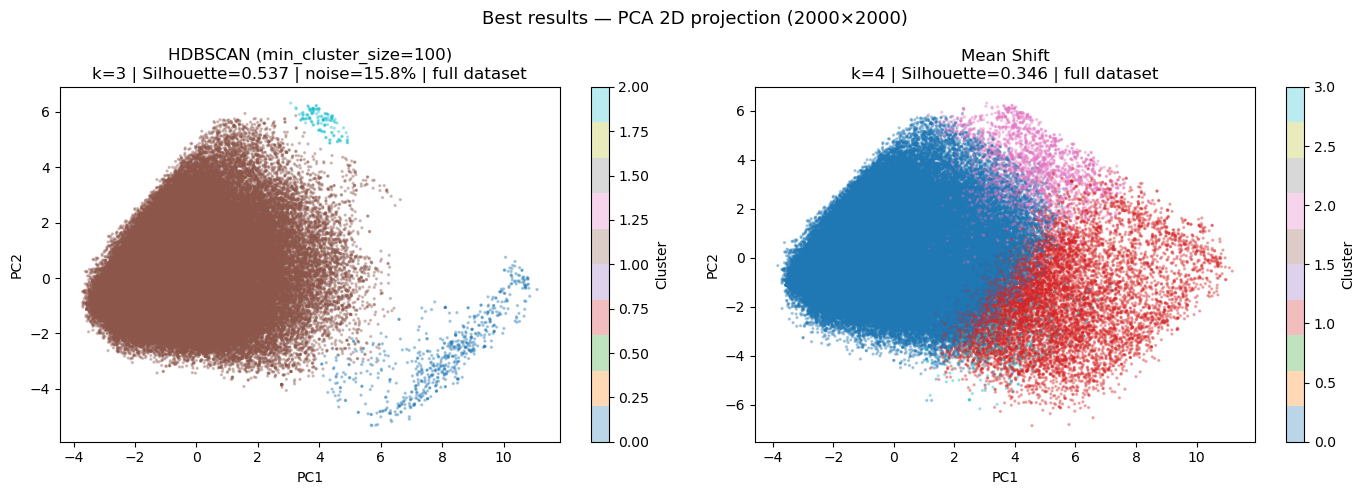

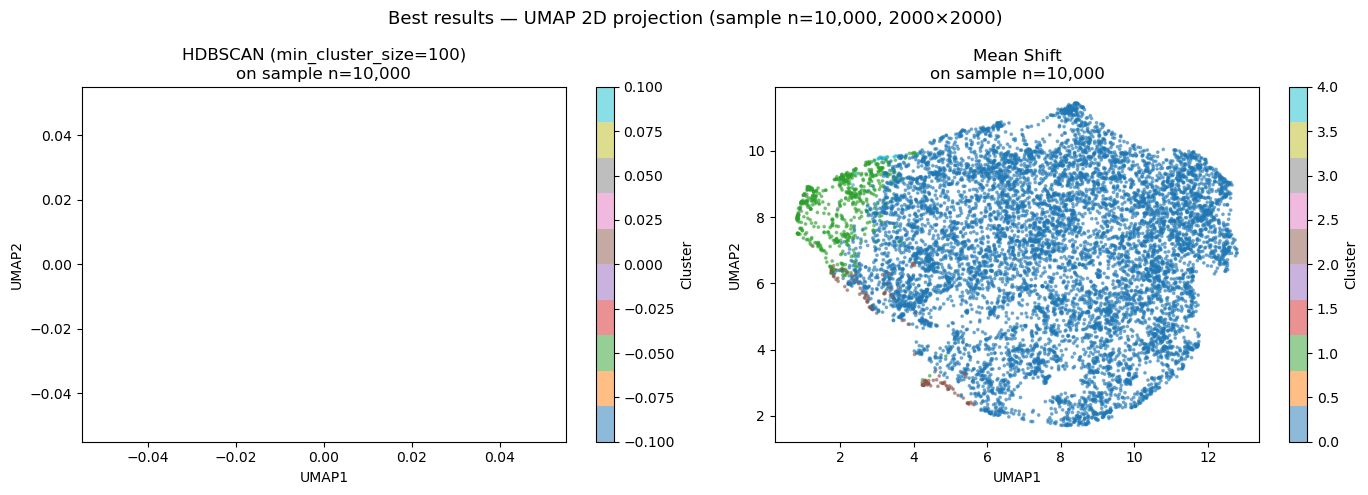

In [40]:
# ── PCA 2D — best results: HDBSCAN vs MeanShift ───────────────────
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_scaled)

print(f"PC1 variance explained: {pca.explained_variance_ratio_[0]*100:.1f}%")
print(f"PC2 variance explained: {pca.explained_variance_ratio_[1]*100:.1f}%")
print(f"Total: {sum(pca.explained_variance_ratio_)*100:.1f}%")

# HDBSCAN min_size=100 — full dataset
hdb_final = HDBSCAN(min_cluster_size=100, min_samples=5,
                    cluster_selection_method='eom')
labels_hdb_final = hdb_final.fit_predict(X_scaled)
mask_hdb  = labels_hdb_final != -1
sil_hdb   = silhouette_score(X_scaled[mask_hdb], labels_hdb_final[mask_hdb],
                             sample_size=10000, random_state=42)
n_hdb     = len(set(labels_hdb_final[mask_hdb]))
noise_hdb = (labels_hdb_final == -1).mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# HDBSCAN
colors_hdb = labels_hdb_final.copy().astype(float)
colors_hdb[labels_hdb_final == -1] = np.nan
scatter1 = axes[0].scatter(X_2d[:, 0], X_2d[:, 1], c=colors_hdb,
                           cmap='tab10', s=2, alpha=0.3)
axes[0].set_title(f'HDBSCAN (min_cluster_size=100)\n'
                  f'k={n_hdb} | Silhouette={sil_hdb:.3f} | '
                  f'noise={noise_hdb:.1f}% | full dataset')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')
plt.colorbar(scatter1, ax=axes[0], label='Cluster')

# MeanShift
scatter2 = axes[1].scatter(X_2d[:, 0], X_2d[:, 1], c=labels_ms_full,
                           cmap='tab10', s=2, alpha=0.3)
axes[1].set_title(f'Mean Shift\n'
                  f'k={n_ms_full} | Silhouette={sil_ms:.3f} | full dataset')
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')
plt.colorbar(scatter2, ax=axes[1], label='Cluster')

plt.suptitle('Best results — PCA 2D projection (2000×2000)', fontsize=13)
plt.tight_layout()
plt.savefig('clustering_best2_pca2d.png', dpi=150, bbox_inches='tight')
plt.show()

# ── UMAP 2D — HDBSCAN vs MeanShift on sample ──────────────────────
reducer_2d = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1,
                       metric='euclidean', random_state=42)
X_umap_2d = reducer_2d.fit_transform(X_sample)

labels_hdb_s = HDBSCAN(min_cluster_size=100, min_samples=5,
                        cluster_selection_method='eom').fit_predict(X_sample)
labels_ms_s  = MeanShift(bandwidth=bandwidth,
                          bin_seeding=True).fit_predict(X_sample)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors_hdb_s = labels_hdb_s.copy().astype(float)
colors_hdb_s[labels_hdb_s == -1] = np.nan
scatter1 = axes[0].scatter(X_umap_2d[:, 0], X_umap_2d[:, 1],
                           c=colors_hdb_s, cmap='tab10', s=3, alpha=0.5)
axes[0].set_title('HDBSCAN (min_cluster_size=100)\non sample n=10,000')
axes[0].set_xlabel('UMAP1'); axes[0].set_ylabel('UMAP2')
plt.colorbar(scatter1, ax=axes[0], label='Cluster')

scatter2 = axes[1].scatter(X_umap_2d[:, 0], X_umap_2d[:, 1],
                           c=labels_ms_s, cmap='tab10', s=3, alpha=0.5)
axes[1].set_title('Mean Shift\non sample n=10,000')
axes[1].set_xlabel('UMAP1'); axes[1].set_ylabel('UMAP2')
plt.colorbar(scatter2, ax=axes[1], label='Cluster')

plt.suptitle('Best results — UMAP 2D projection (sample n=10,000, 2000×2000)',
             fontsize=13)
plt.tight_layout()
plt.savefig('clustering_best2_umap.png', dpi=150, bbox_inches='tight')
plt.show()

In [39]:
# ── Verificar si los clusters son reales — dataset 2000×2000 ──────

# ── HDBSCAN min_size=100 — modelo final ───────────────────────────
hdb_check = HDBSCAN(min_cluster_size=100, min_samples=5,
                    cluster_selection_method='eom')
labels_hdb_check = hdb_check.fit_predict(X_scaled)

df_check = df_clean.copy()
df_check['cluster_hdb'] = labels_hdb_check
df_hdb = df_check[labels_hdb_check != -1].copy()

print("=== HDBSCAN min_size=100 — cluster sizes ===")
print(pd.Series(labels_hdb_check).value_counts().sort_index())

print("\n=== Equivalent diameter per cluster ===")
print(df_hdb.groupby('cluster_hdb')['equivalent_diameter'].describe().round(3))

print("\n=== Solidity per cluster ===")
print(df_hdb.groupby('cluster_hdb')['solidity'].describe().round(3))

print("\n=== Aspect ratio per cluster ===")
print(df_hdb.groupby('cluster_hdb')['aspect_ratio'].describe().round(3))

print("\n=== Median per cluster — all variables ===")
cols_show = ['equivalent_diameter', 'roundness', 'aspect_ratio',
             'solidity', 'feret_ratio', 'mean_intensity',
             'std_intensity', 'glcm_correlation', 'lbp_mean']
print(df_hdb.groupby('cluster_hdb')[cols_show].median().round(3).T.to_string())

print("\n=== Std per cluster — all variables ===")
print(df_hdb.groupby('cluster_hdb')[cols_show].std().round(3).T.to_string())

# ── MeanShift full dataset ─────────────────────────────────────────
df_check['cluster_ms'] = labels_ms_full

print("\n\n=== MeanShift — cluster sizes ===")
print(pd.Series(labels_ms_full).value_counts().sort_index())

print("\n=== Equivalent diameter per cluster ===")
print(df_check.groupby('cluster_ms')['equivalent_diameter'].describe().round(3))

print("\n=== Solidity per cluster ===")
print(df_check.groupby('cluster_ms')['solidity'].describe().round(3))

print("\n=== Median per cluster — all variables ===")
print(df_check.groupby('cluster_ms')[cols_show].median().round(3).T.to_string())

print("\n=== Std per cluster — all variables ===")
print(df_check.groupby('cluster_ms')[cols_show].std().round(3).T.to_string())

=== HDBSCAN min_size=100 — cluster sizes ===
-1     28092
 0       644
 1    148405
 2       136
Name: count, dtype: int64

=== Equivalent diameter per cluster ===
                count    mean    std     min     25%     50%     75%     max
cluster_hdb                                                                 
0               644.0   8.621  3.712   3.909   5.863   7.569  10.357  17.806
1            148405.0   6.012  2.214   3.909   4.514   5.293   6.864  17.806
2               136.0  17.708  0.306  16.274  17.806  17.806  17.806  17.806

=== Solidity per cluster ===
                count   mean    std    min    25%    50%    75%    max
cluster_hdb                                                           
0               644.0  0.449  0.082  0.301  0.388  0.444  0.505  0.680
1            148405.0  0.831  0.118  0.394  0.750  0.857  0.926  1.000
2               136.0  0.516  0.059  0.386  0.467  0.522  0.561  0.641

=== Aspect ratio per cluster ===
                count   mean    

## Cluster validity check — comparison with 1,000×1,000 dataset

At 1,000×1,000 resolution, cluster validity analysis revealed that 5 of
9 UMAP+HDBSCAN clusters were artefactual — groups of particles with
`equivalent_diameter std=0` and `solidity std=0`, indicating identical
discrete pixel areas rather than distinct morphologies.

At 2,000×2,000 resolution, the same analysis on HDBSCAN (min_size=100)
and Mean Shift confirms that **all clusters are morphologically genuine**:

- No cluster shows `equivalent_diameter std=0` or `solidity std=0`
- All clusters have real internal variance across geometric variables
- The only cluster with low std is HDBSCAN cluster 2 (n=136,
  equivalent_diameter std=0.306) — not a discretization artefact but
  a naturally homogeneous group of large dark particles all near the
  maximum detectable size (equivalent_diameter≈17.8px)

Each cluster has a distinct and physically interpretable profile:

**HDBSCAN (min_size=100) — 3 clusters:**
- Cluster 1 (148k, 84%): fine particles — circular, convex
  (roundness=1.05, solidity=0.86, lbp=98)
- Cluster 0 (644, 0.4%): elongated/fibrous particles
  (aspect=3.31, solidity=0.44, feret=0.33)
- Cluster 2 (136, 0.08%): large dark aggregates
  (diam=17.8, intensity=54, roundness=0.14)

**MeanShift (full dataset) — 4 clusters:**
- Cluster 0 (163k, 92%): fine circular particles
  (roundness=1.04, solidity=0.84)
- Cluster 1 (10k, 5.8%): elongated irregular particles
  (aspect=3.19, solidity=0.54, feret=0.34)
- Cluster 2 (2.6k, 1.4%): large dark aggregates
  (diam=17.2, intensity=103, solidity=0.61)
- Cluster 3 (698, 0.4%): small elongated particles
  (aspect=3.53, feret=0.31)

The resolution increase from 1,000×1,000 to 2,000×2,000 successfully
eliminated pixel-area quantization artefacts, producing clusters that
reflect genuine morphological differences between particle types.